In [1]:
# PREÁMBULO: carga de datos del notebook de preparación


import pandas as pd
import os

# Ruta relativa al CSV generado por el otro notebook
ruta_csv = os.path.join("..", "data", "close_approaches.csv")

if not os.path.exists(ruta_csv):
    raise FileNotFoundError(
        f"No se encontró el CSV en {ruta_csv}. "
        f"Ejecutar primero data/ProyectoNeoRework_data.ipynb")

df = pd.read_csv(ruta_csv)

# Limpieza de fechas (quitar incertidumbre ±)
def limpiar_fecha(fecha_str):
    if isinstance(fecha_str, str):
        return fecha_str.split("±")[0].strip()
    return fecha_str

df["Close-Approach (CA) Date"] = df["Close-Approach (CA) Date"].apply(limpiar_fecha)

# Definimos las variables que usaremos en todo el análisis
features = ["CA DistanceNominal (au)", "V relative(km/s)",
            "V infinity(km/s)", "H(mag)", "Diameter(km)"]

print(f"Dataset cargado: {len(df):,} registros")

Dataset cargado: 32,345 registros


## Limpieza de datos

In [2]:
df.isna().sum()

Object                       0
Close-Approach (CA) Date     0
CA DistanceNominal (au)      0
CA DistanceMinimum (au)      0
V relative(km/s)             0
V infinity(km/s)            18
H(mag)                       8
Diameter(km)                 7
Std Diameter(km)             7
dtype: int64

In [3]:
# Eliminamos filas que tengan NaN en las features que vamos a usar
# Así no perdemos registros por culpa de columnas irrelevantes
df = df.dropna(subset=features)
print(f"Filas tras limpieza: {len(df):,}")

Filas tras limpieza: 32,319


# Preparacion de modelos

Ahora se implementarán modelos de regresión junto con técnicas de machine learning, específicamente PCA y K-Means, con el objetivo de realizar un análisis exploratorio avanzado del espacio de datos. Esto permitirá evaluar la estructura subyacente, identificar patrones y medir la efectividad de estos enfoques, determinando si el problema requiere la aplicación de métodos más sofisticados o de mayor capacidad predictiva.


## PCA

El PCA (Análisis de Componentes Principales) es una técnica de reducción de dimensionalidad que transforma un conjunto de variables originales, posiblemente correlacionadas, en un nuevo conjunto de variables no correlacionadas llamadas componentes principales. Su funcionamiento se basa en identificar las direcciones del espacio de datos donde la varianza es máxima, utilizando la descomposición en autovalores y autovectores de la matriz de covarianza. De esta forma, los primeros componentes concentran la mayor cantidad de información, permitiendo proyectar los datos en un espacio de menor dimensión con mínima pérdida de variabilidad, lo que facilita su análisis, visualización y modelado.


### Librerias

In [4]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

### Preparacion de datos




In [5]:
# Fijamos la semilla para que los resultados sean reproducibles
random_state = 20

# df ya fue limpiado arriba (dropna en features), solo seleccionamos
X = df[features]

# Estandarización: cada variable pasa a tener media 0 y desv. estándar 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Dataset final: {X_scaled.shape[0]} muestras x {X_scaled.shape[1]} features")

Dataset final: 32319 muestras x 5 features


In [6]:
# PCA completo: extraemos las 5 componentes principales
# Esto nos permite ver cuánta varianza captura cada una
pca_full = PCA(random_state=random_state)
coords_full = pca_full.fit_transform(X_scaled)

# Varianza explicada por cada componente
exp_var = pca_full.explained_variance_ratio_ * 100
var_acum = np.cumsum(exp_var)

print("Varianza explicada por componente:")
for i, var in enumerate(exp_var):
    print(f"  PC{i+1}: {var:.1f}%")
print(f"\nAcumulado PC1+PC2: {var_acum[1]:.1f}%")

# Loadings: qué variables pesan más en cada componente
# Nos ayuda a interpretar el significado físico de cada PC
loadings = pd.DataFrame(
    pca_full.components_.T,
    columns=[f"PC{i+1}" for i in range(5)],
    index=features
)
print("\nLoadings (contribución de cada variable):")
print(loadings.round(3))

# Interpretación rápida: top 2 variables por componente
for pc in ["PC1", "PC2"]:
    top = loadings[pc].abs().sort_values(ascending=False).head(2)
    print(f"\n{pc} -> dominado por: {', '.join(top.index)}")

# Decisión: ¿PCA es suficiente o necesitamos clustering?
PCA_UMBRAL = 80.0
pca_suficiente = var_acum[1] >= PCA_UMBRAL
print(f"\n{'✓' if pca_suficiente else '✗'} PCA {'suficiente' if pca_suficiente else 'insuficiente'} "
      f"(PC1+PC2={var_acum[1]:.1f}% {'≥' if pca_suficiente else '<'} {PCA_UMBRAL:.0f}%)")

# Proyección a 2D para visualización
coords_2d = coords_full[:, :2]

Varianza explicada por componente:
  PC1: 49.5%
  PC2: 28.3%
  PC3: 15.8%
  PC4: 6.4%
  PC5: 0.0%

Acumulado PC1+PC2: 77.8%

Loadings (contribución de cada variable):
                           PC1    PC2    PC3    PC4    PC5
CA DistanceNominal (au)  0.143  0.594  0.727  0.313 -0.005
V relative(km/s)         0.549 -0.400  0.176  0.091 -0.707
V infinity(km/s)         0.551 -0.394  0.182  0.085  0.708
H(mag)                  -0.469 -0.429  0.114  0.764  0.005
Diameter(km)             0.393  0.384 -0.628  0.551  0.003

PC1 -> dominado por: V infinity(km/s), V relative(km/s)

PC2 -> dominado por: CA DistanceNominal (au), H(mag)

✗ PCA insuficiente (PC1+PC2=77.8% < 80%)


### Visualizacion

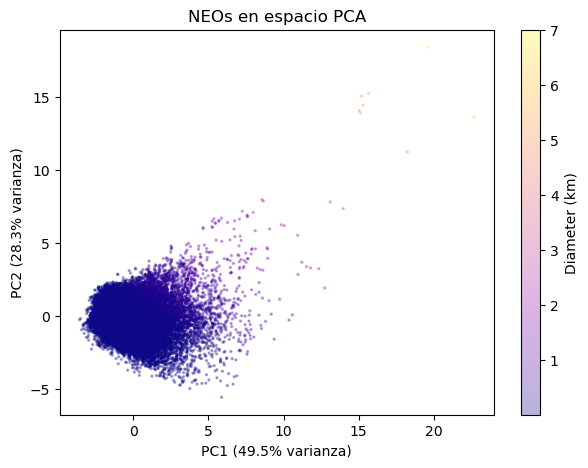

PCA insuficiente. Se aplicara K-Means sobre las 5 dimensiones originales.


In [7]:
plt.figure(figsize=(7, 5))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1],
            c=X["Diameter(km)"], cmap="plasma", s=2, alpha=0.3)
plt.colorbar(label="Diameter (km)")
plt.title("NEOs en espacio PCA")
plt.xlabel(f"PC1 ({exp_var[0]:.1f}% varianza)")
plt.ylabel(f"PC2 ({exp_var[1]:.1f}% varianza)")
plt.show()

if pca_suficiente:
    print("PCA captura suficiente varianza. Los loadings revelan la estructura fisica.")
else:
    print("PCA insuficiente. Se aplicara K-Means sobre las 5 dimensiones originales.")

### Nota

PC1 y PC2 son ejes artificiales creados por el PCA que resumen la información de las 5 variables originales en 2 dimensiones. La interpretación física de cada PC se obtiene de los loadings (pesos de cada variable original en cada componente). Los valores en estos ejes no tienen unidades físicas directas sino que representan qué tan lejos está cada asteroide del promedio en esas direcciones. Si PC1+PC2 >= 80%, el PCA es suficiente para entender la estructura de los datos; de lo contrario, se requiere K-Means.

### Interpretacion

El PCA completo revela cuánta varianza explica cada componente y qué variables físicas dominan cada eje (loadings). Si PC1+PC2 >= 80%, la proyección 2D retiene suficiente información y no es necesario clusterizar. Si es menor, se procede con K-Means sobre los 5D escalados para capturar la estructura que el PCA pierde.

## K-Means

K-Means es un algoritmo de aprendizaje no supervisado utilizado para agrupar datos en K clusters según su similitud. Funciona asignando cada punto al centroide más cercano y recalculando iterativamente estos centroides como el promedio de los puntos del grupo, con el objetivo de minimizar la variabilidad interna de cada cluster (distancia entre los puntos y su centro). De esta manera, permite identificar patrones o estructuras en los datos sin necesidad de una variable objetivo.

### Librerias

In [8]:
from sklearn.cluster import KMeans

### Metodo del codo

El método del codo se utiliza para determinar el número óptimo de clusters (K) en algoritmos como K-Means. Consiste en ejecutar el modelo con distintos valores de K y medir la suma de errores dentro de los clusters (inercia o WCSS). A medida que K aumenta, el error disminuye, pero llega un punto donde la mejora deja de ser significativa; ese punto de inflexión, que visualmente parece un “codo” en la gráfica, indica el número adecuado de clusters, ya que representa un equilibrio entre simplicidad del modelo y buena representación de los datos.

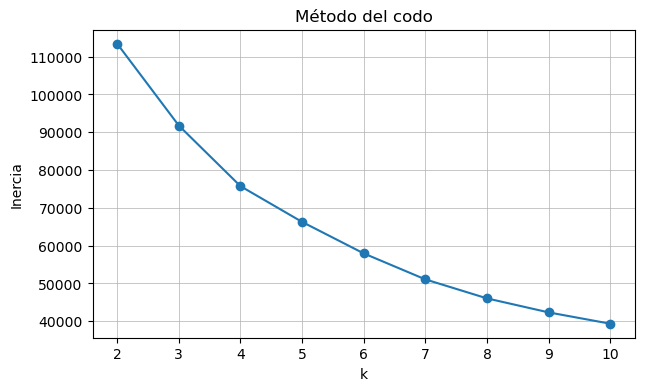

k seleccionado: 4


In [9]:
# Buscamos el k óptimo con el método del codo
k_range = range(2, 11)
inercias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inercias, marker="o")
plt.title("Método del codo")
plt.xlabel("k")
plt.ylabel("Inercia")
plt.xticks(list(k_range))
plt.grid(True, lw=0.5)
plt.show()

# El codo sugiere k≈4; usamos 4 clusters por criterio visual
k_opt = 4
print(f"k seleccionado: {k_opt}")

### Aplicacion del modelo (5D escalados, no sobre PCA)


In [10]:
# Clustering final en el espacio completo (5 dimensiones)
# Es importante hacerlo aquí, no en el espacio reducido de PCA
km = KMeans(n_clusters=4, random_state=random_state, n_init=10)
etiquetas = km.fit_predict(X_scaled)

# Proyectamos a 2D solo para visualizar, no para clusterizar
coords_2d = PCA(n_components=2, random_state=random_state).fit_transform(X_scaled)

print(f"Clusters encontrados: k={4}")

Clusters encontrados: k=4


### Visualizacion

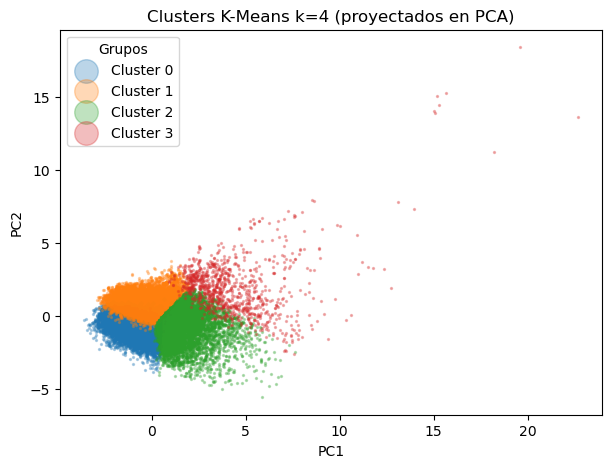

In [11]:
plt.figure(figsize=(7, 5))

# Un scatter por cluster para que aparezca en la leyenda
for c in sorted(np.unique(etiquetas)):
    mask = etiquetas == c
    plt.scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                label=f"Cluster {c}", s=2, alpha=0.3)

plt.title(f"Clusters K-Means k={4} (proyectados en PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(markerscale=12, title="Grupos", loc="best")
plt.show()

### Distribucion de clusters

In [12]:
# Agregamos las etiquetas de cluster al dataset original
X_con_cluster = X.copy()
X_con_cluster["Cluster"] = etiquetas

# Caracterizamos cada cluster con las medias de sus variables
print("Medias por cluster (escala original):")
print(X_con_cluster.groupby("Cluster")[features].mean().round(4))

# Interpretación: comparar estos valores nos dice qué tipo de NEOs agrupa cada cluster

Medias por cluster (escala original):
         CA DistanceNominal (au)  V relative(km/s)  V infinity(km/s)   H(mag)  \
Cluster                                                                         
0                         0.0119            8.5512            8.4660  27.0487   
1                         0.0367            7.6452            7.6329  25.3379   
2                         0.0263           17.1206           17.1068  24.3798   
3                         0.0340           17.0174           17.0104  19.0055   

         Diameter(km)  
Cluster                
0              0.0179  
1              0.0444  
2              0.0721  
3              0.6782  


### Interpretaciones
El análisis de K-Means sobre las 5 dimensiones originales (no sobre PCA) revela la estructura real de los datos. El k óptimo se elige maximizando el silhouette score, que mide cohesión intra-cluster vs. separación inter-cluster. La tabla de medias por cluster caracteriza cada grupo en las variables físicas originales, permitiendo interpretar qué tipo de NEO agrupa cada uno.

## t-SNE (t-distributed Stochastic Neighbor Embedding)

Técnica de reducción de dimensionalidad no lineal, diseñada principalmente para visualizar datos de alta dimensión en 2D o 3D.

Su principio central es preservar las relaciones locales: si dos puntos son cercanos en el espacio original, deben seguir siéndolo en la proyección. Para lograrlo:

1) Modela la similitud entre puntos del espacio original como probabilidades.
2) Hace lo mismo en el espacio reducido, usando una distribución t de Student (de ahí la "t").
3) Ajusta iterativamente la proyección para que ambas distribuciones sean lo más parecidas posible.

In [13]:
import numpy as np
import pandas as pd
import optuna
from openTSNE import TSNE
from sklearn.manifold import trustworthiness

In [ ]:
# Suprimir logs de Optuna para mantener la salida limpia
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Número de combinaciones de hiperparámetros a explorar
N_TRIALS = 200

def objective(trial):
    """Evalúa una configuración de t-SNE y devuelve su trustworthiness."""

    # Espacio de búsqueda de hiperparámetros
    params = {
        "perplexity":         trial.suggest_int("perplexity", 2, 100),
        "early_exaggeration": trial.suggest_int("early_exaggeration", 4, 50),
        "learning_rate":      trial.suggest_int("learning_rate", 100, 1000),
        "n_iter":             trial.suggest_int("n_iter", 250, 2000),
    }

    # Ajuste inicial del embedding
    tsne = TSNE(**params, random_state=random_state, verbose=False)
    embedding = tsne.fit(X_scaled)

    # Refinamiento adicional del embedding
    embedding.optimize(n_iter=1500, learning_rate=500, inplace=True, verbose=False)

    # Métricas puramente geométricas, sin labels
    trust = trustworthiness(X_scaled, embedding, n_neighbors=15)
    kl    = float(embedding.kl_divergence)  # openTSNE lo guarda en el objeto

    # Guardar métricas como atributos del trial para análisis posterior
    trial.set_user_attr("trustworthiness", round(trust, 4))
    trial.set_user_attr("kl_divergence",   round(kl, 4))

    return trust  # maximizar preservación de vecindarios


# Configuración del estudio: maximizar trustworthiness con muestreo bayesiano
study = optuna.create_study(
    direction  = "maximize",
    study_name = "tsne_optimization",
    sampler    = optuna.samplers.TPESampler(seed=42),
    pruner     = optuna.pruners.MedianPruner(),
)

# Ejecución paralela de los trials
study.optimize(
    objective,
    n_trials          = N_TRIALS,
    n_jobs            = -1,
    show_progress_bar = True,
)

print("\n Mejores parámetros encontrados:")
print(study.best_params)
print(f"   Trustworthiness: {study.best_value:.4f}")

# Recolección de resultados de todos los trials
rows = []
for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        rows.append({
            **trial.params,
            "trustworthiness": trial.user_attrs.get("trustworthiness"),
            "kl_divergence":   trial.user_attrs.get("kl_divergence"),
            "status": "ok",
        })
    else:
        rows.append({**trial.params, "status": "error/pruned"})

# Exportar resultados a CSV
df_results = pd.DataFrame(rows)
df_results.to_csv("tsne_optuna_results.csv", index=False)
print("✓ Guardado en tsne_optuna_results.csv")

# Top 10 configuraciones por trustworthiness
print("\n Top 10 configuraciones:")
print(
    df_results[df_results["status"] == "ok"]
    .sort_values("trustworthiness", ascending=False)
    .head(10)
    .to_string(index=False)
)

  0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
TOP_N = 10

df_results = pd.read_csv("tsne_optuna_results.csv")
top_configs = (
    df_results[df_results["status"] == "ok"]
    .sort_values("trustworthiness", ascending=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

for rank, row in top_configs.iterrows():
    params = {
        "perplexity":         int(row["perplexity"]),
        "early_exaggeration": int(row["early_exaggeration"]),
        "learning_rate":      int(row["learning_rate"]),
        "n_iter":             int(row["n_iter"]),
    }

    tsne      = TSNE(**params, random_state=random_state, verbose=False)
    embedding = tsne.fit(X_scaled)
    embedding.optimize(n_iter=1500, learning_rate=500, inplace=True, verbose=False)

    df_emb = pd.DataFrame({
        "x": embedding[:, 0],
        "y": embedding[:, 1],
        # métricas de la config
        "trustworthiness": row["trustworthiness"],
        "kl_divergence":   row["kl_divergence"],
        # parámetros usados
        "perplexity":         params["perplexity"],
        "early_exaggeration": params["early_exaggeration"],
        "learning_rate":      params["learning_rate"],
        "n_iter":             params["n_iter"],
    })

    filename = (
        f"tsne_rank{rank+1:02d}"
        f"_trust{row['trustworthiness']:.4f}"
        f"_kl{row['kl_divergence']:.4f}"
        f"_perp{params['perplexity']}"
        f"_ee{params['early_exaggeration']}"
        f"_lr{params['learning_rate']}"
        f"_iter{params['n_iter']}"
        f".csv"
    )
    df_emb.to_csv(filename, index=False)
    print(f"[{rank+1:>2}/{TOP_N}] ✓ {filename}")

print(f"\nListos {TOP_N} CSVs con coordenadas x/y puras del embedding.")

# Clasificación de peligrosidad (PHA)

El análisis previo (PCA / K-Means / t-SNE) es **exploratorio**. Aquí abordamos la
pregunta central, con rigor de validación:

> **¿Se puede inferir el carácter potencialmente peligroso (PHA) de un NEO a partir
> únicamente de la cinemática de sus aproximaciones observadas — sin los elementos
> orbitales (MOID, a, e, i) que lo definen — y cómo distorsiona esa inferencia la
> función de selección observacional?**

`MOID`, `H_SBDB` y los metadatos de observación (`first_obs_year`, `data_arc`) se usan
**solo para etiquetar/validar/analizar selección**, nunca como variables predictoras.

## Agregación a nivel objeto

La peligrosidad es propiedad del **objeto**. Agregamos los eventos por `Object`,
resumiendo cinemática observada e historia de observación.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

obj = df.groupby("Object").agg(
    distmin_min=("CA DistanceMinimum (au)", "min"),
    distnom_min=("CA DistanceNominal (au)", "min"),
    vrel_max=("V relative(km/s)", "max"),
    vrel_med=("V relative(km/s)", "median"),
    vinf_med=("V infinity(km/s)", "median"),
    H_obs=("H(mag)", "min"),
    diam_max=("Diameter(km)", "max"),
    n_appro=("Object", "size"),
    first_obs_year=("first_obs_year", "max"),
    data_arc=("data_arc(d)", "max"),
    pha=("PHA_official", "max"),
).reset_index().dropna(subset=["pha"])
obj["pha"] = obj["pha"].astype(int)
print(f"Objetos: {len(obj):,} | PHA: {obj['pha'].sum():,} ({100*obj['pha'].mean():.1f}%)  "
      f"(1 PHA por cada {int((obj['pha']==0).sum()/obj['pha'].sum())} no-PHA)")

## Colinealidad y poda de features

Varias features son redundantes: el diámetro se imputa desde `H` (dependientes) y las
tres velocidades son casi idénticas. Lo verificamos y definimos conjuntos **podados**.

In [ ]:
cand = ["distmin_min","distnom_min","vrel_max","vrel_med","vinf_med","H_obs","diam_max","n_appro"]
Cmat = obj[cand].corr().abs()
plt.figure(figsize=(6.5,5.5))
im=plt.imshow(Cmat, cmap="magma", vmin=0, vmax=1); plt.colorbar(im, label="|Pearson r|")
plt.xticks(range(len(cand)), cand, rotation=45, ha="right"); plt.yticks(range(len(cand)), cand)
plt.title("Colinealidad de features (nivel objeto)")
plt.tight_layout(); plt.savefig("../results/figures/clf_collinearity.png", dpi=110); plt.show()
print("Pares |corr|>0.9:")
for i,a in enumerate(cand):
    for b in cand[i+1:]:
        if Cmat.loc[a,b]>0.9: print(f"  {a} ~ {b}: {Cmat.loc[a,b]:.3f}")

# Conjuntos podados (una velocidad, una distancia)
FEAT = {
    "kin+size": ["distmin_min","vrel_max","H_obs","n_appro"],
    "kin-only": ["distmin_min","vrel_max","n_appro"],
    "size-only":["H_obs"],
}

## Clasificación supervisada con validación cruzada

Repeated Stratified K-Fold (5×3). Métrica principal **F2** (prioriza recall) más
**PR-AUC** y **ROC-AUC**; reportamos media ± desv. estándar. *Accuracy se omite.*

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.metrics import fbeta_score, make_scorer
from xgboost import XGBClassifier

random_state = 20
y = obj["pha"].values
spw = (y==0).sum()/max((y==1).sum(),1)

def make_models():
    return {
        "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000,
                     class_weight="balanced", random_state=random_state)),
        "RandForest": RandomForestClassifier(n_estimators=200, class_weight="balanced",
                     random_state=random_state, n_jobs=1),
        "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                     random_state=random_state, eval_metric="logloss", scale_pos_weight=spw, n_jobs=1),
    }

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=random_state)
scoring = {"F2": make_scorer(fbeta_score, beta=2), "PR-AUC":"average_precision", "ROC-AUC":"roc_auc"}
rows=[]
for fset, cols in FEAT.items():
    X = obj[cols].fillna(obj[cols].median()).values
    for mname, m in make_models().items():
        sc = cross_validate(m, X, y, cv=cv, scoring=scoring, n_jobs=1)
        rows.append({"features":fset, "model":mname,
                     "F2":sc['test_F2'].mean(), "F2_std":sc['test_F2'].std(),
                     "PR-AUC":sc['test_PR-AUC'].mean(), "ROC-AUC":sc['test_ROC-AUC'].mean()})
tabla = pd.DataFrame(rows)
print(tabla.round(3).to_string(index=False))

In [ ]:
# Figura: F2 por feature set x modelo (barras con error)
sets=list(FEAT); mods=sorted(tabla['model'].unique()); w=0.8/len(mods)
plt.figure(figsize=(7.5,4))
for j,mod in enumerate(mods):
    sub=tabla[tabla.model==mod].set_index('features').reindex(sets)
    plt.bar([i+j*w for i in range(len(sets))], sub['F2'], w, yerr=sub['F2_std'], capsize=3, label=mod)
plt.xticks([i+0.4-w/2 for i in range(len(sets))], sets); plt.ylim(0,1.05)
plt.ylabel("F2 (5x3 CV)"); plt.legend(fontsize=8); plt.title("Señal de peligrosidad por conjunto de features")
plt.tight_layout(); plt.savefig("../results/figures/clf_f2_por_features.png", dpi=110); plt.show()

## Circularidad / *leakage*

PHA se **define** por `MOID≤0.05 au` y `H≤22`. Una regla de dos umbrales sobre lo
observado iguala al ML → el desempeño casi perfecto es en gran parte un artefacto de
alimentar (proxies de) la propia definición. Y **sin tamaño** (kin-only) el F2 se
desploma: la señal de peligro la aporta el tamaño, no la cinemática.

In [ ]:
from sklearn.metrics import fbeta_score, precision_score, recall_score
regla = ((obj["distmin_min"]<=0.05)&(obj["H_obs"]<=22)).astype(int).values
print(f"Baseline regla de umbral:  F2={fbeta_score(y,regla,beta=2):.3f}  "
      f"prec={precision_score(y,regla):.3f}  rec={recall_score(y,regla):.3f}")

## Curvas PR / ROC y umbral de decisión

Probabilidades fuera de fold (StratifiedKFold). Reportamos el umbral que maximiza F2,
en vez de asumir 0.5.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import precision_recall_curve, roc_curve, auc, average_precision_score
cols=FEAT["kin+size"]; X=obj[cols].fillna(obj[cols].median()).values
skf=StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
proba=cross_val_predict(make_models()["XGBoost"], X, y, cv=skf, method="predict_proba", n_jobs=1)[:,1]
prec,rec,thr=precision_recall_curve(y,proba); f2c=(5*prec*rec)/(4*prec+rec+1e-12)
bi=int(np.nanargmax(f2c[:-1])); fpr,tpr,_=roc_curve(y,proba)
fig,ax=plt.subplots(1,2,figsize=(11,4.2))
ax[0].plot(rec,prec,color="#d95f0e"); ax[0].axhline(y.mean(),color="gray",ls=":",label="azar")
ax[0].scatter(rec[bi],prec[bi],color="k",zorder=5,label=f"umbral F2-opt={thr[bi]:.2f}")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision"); ax[0].set_title(f"PR (AP={average_precision_score(y,proba):.3f})"); ax[0].legend(fontsize=8)
ax[1].plot(fpr,tpr,color="#2c7fb8"); ax[1].plot([0,1],[0,1],"k:",label="azar")
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR"); ax[1].set_title(f"ROC (AUC={auc(fpr,tpr):.3f}) [XGB, kin+size]"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig("../results/figures/clf_pr_roc.png", dpi=110); plt.show()
print(f"Umbral F2-óptimo: {thr[bi]:.3f}  (vs 0.5 por defecto)")

## Importancia de variables (SHAP)

El tamaño (`H_obs`) domina; la cinemática casi no contribuye — coherente con que PHA
está dominado por el corte de tamaño.

In [ ]:
import shap
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=random_state, n_jobs=1).fit(X,y)
imp=pd.Series(rf.feature_importances_, index=cols).sort_values()
plt.figure(figsize=(7,3.5)); plt.barh(imp.index, imp.values, color="#756bb1")
plt.title("Importancia de variables (RandomForest, kin+size)"); plt.xlabel("importancia")
plt.tight_layout(); plt.savefig("../results/figures/clf_importancia.png", dpi=110); plt.show()

samp=pd.DataFrame(X, columns=cols).sample(min(2000,len(X)), random_state=random_state)
sv=np.array(shap.TreeExplainer(rf).shap_values(samp))
if sv.ndim==3: sv = sv[...,1] if sv.shape[-1]==2 else sv[1]
plt.figure(); shap.summary_plot(sv, samp, show=False)
plt.tight_layout(); plt.savefig("../results/figures/clf_shap.png", dpi=110, bbox_inches="tight"); plt.show()

## Selección observacional (por fecha real de descubrimiento)

Usamos `first_obs_year` (primera observación astrométrica, SBDB), no el año del primer
evento de aproximación. La prevalencia de PHA cae monótonamente con la época de
descubrimiento, y el **arco orbital** (`data_arc`) — proxy de caracterización — la
acompaña: el confundidor es explícito.

In [ ]:
o=obj.dropna(subset=["first_obs_year"]).copy(); o["dec"]=(o["first_obs_year"]//10*10).astype(int)
g=o.groupby("dec").agg(n=("pha","size"),prev=("pha","mean"),arc=("data_arc","median")); g=g[g["n"]>=5]
fig,ax1=plt.subplots(figsize=(7.5,4))
ax1.bar(g.index, g["prev"]*100, width=7, color="#31a354", alpha=0.8)
ax1.set_ylabel("Prevalencia PHA (%)", color="#31a354"); ax1.set_xlabel("Década de primera observación")
ax2=ax1.twinx(); ax2.plot(g.index, g["arc"], "o-", color="#756bb1"); ax2.set_yscale("symlog")
ax2.set_ylabel("Arco orbital mediano (días)", color="#756bb1")
ax1.set_title("Función de selección: prevalencia PHA vs época de descubrimiento")
plt.tight_layout(); plt.savefig("../results/figures/selection_temporal.png", dpi=110); plt.show()

cut=2015; tr=o[o.first_obs_year<cut]; te=o[o.first_obs_year>=cut]
print(f"Hold-out temporal first_obs<{cut}: train={len(tr)} (PHA {100*tr['pha'].mean():.1f}%) "
      f"-> test={len(te)} (PHA {100*te['pha'].mean():.1f}%)")
print(f"corr(data_arc, PHA) = {o['data_arc'].corr(o['pha']):.3f}")

## Sesgo de muestreo

El catálogo está condicionado a objetos con aproximaciones cercanas. Comparado con el
total de NEOs (SBDB), la prevalencia PHA está sólo levemente enriquecida — la selección
dominante es temporal (descubrimiento), no el condicionamiento por aproximación.

In [ ]:
import os
ruta_sb=os.path.join("..","data","sbdb_neo.csv")
if os.path.exists(ruta_sb):
    sb=pd.read_csv(ruta_sb); full=(sb["pha"].astype(str)=="Y").mean(); cad=y.mean()
    plt.figure(figsize=(5,4))
    plt.bar(["todos los NEOs\n(SBDB)","aproximadores\n(este catálogo)"], [full*100,cad*100], color=["#9ecae1","#08519c"])
    for i,v in enumerate([full*100,cad*100]): plt.text(i,v,f"{v:.1f}%",ha="center",va="bottom")
    plt.ylabel("Prevalencia PHA (%)"); plt.title("Sesgo de muestreo: enriquecimiento PHA")
    plt.tight_layout(); plt.savefig("../results/figures/selection_sampling.png", dpi=110); plt.show()
    print(f"PHA: todos NEOs={full*100:.2f}%  aproximadores={cad*100:.1f}%")

## Proxy vs oficial: ¿aproxima la distancia observada al MOID?

La distancia mínima observada es un sustituto fuerte pero imperfecto del MOID (rara vez
se observa la aproximación más cercana posible → la observada tiende a ser mayor).

In [ ]:
po=df.drop_duplicates("Object").dropna(subset=["PHA_official","MOID (au)"])
corr=po["CA DistanceMinimum (au)"].corr(po["MOID (au)"])
plt.figure(figsize=(5.5,5.5))
plt.scatter(po["MOID (au)"], po["CA DistanceMinimum (au)"], s=3, alpha=0.2)
plt.plot([0,0.5],[0,0.5],"r--",lw=1,label="y = x")
plt.axvline(0.05,color="g",ls=":",lw=1); plt.axhline(0.05,color="g",ls=":",lw=1)
plt.xlim(0,0.5); plt.ylim(0,0.5)
plt.xlabel("MOID oficial (au)"); plt.ylabel("dist_min observada (au)")
plt.title(f"Observada vs MOID (r={corr:.3f})"); plt.legend()
plt.tight_layout(); plt.savefig("../results/figures/proxy_vs_moid.png", dpi=110); plt.show()

## Conclusiones

1. **Clasificar PHA es casi trivial y casi circular:** una regla de dos umbrales sobre
   lo observado iguala a RandomForest/XGBoost (F2≈0.98, ROC≈0.999).
2. **La señal la aporta el tamaño, no la cinemática:** sin `H` (kin-only) el F2 cae a
   ~0.2–0.5; `size-only` casi iguala a `kin+size` (SHAP lo confirma).
3. **El catálogo es un registro de detección:** la prevalencia PHA cae de ~95% a ~1% con
   la época de descubrimiento, acompañada por el arco orbital — efecto de selección.
4. **La distancia observada aproxima el MOID** (r≈0.7–0.8) pero no lo iguala; esa brecha
   es física, no ruido.